In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

print("All libraries loaded!")

All libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
df = pd.read_csv('Resume.csv')
print("Shape:", df.shape)
df.head()

Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.columns
df['Category'].nunique()
df['Category'].value_counts()


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_4644\2911361086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


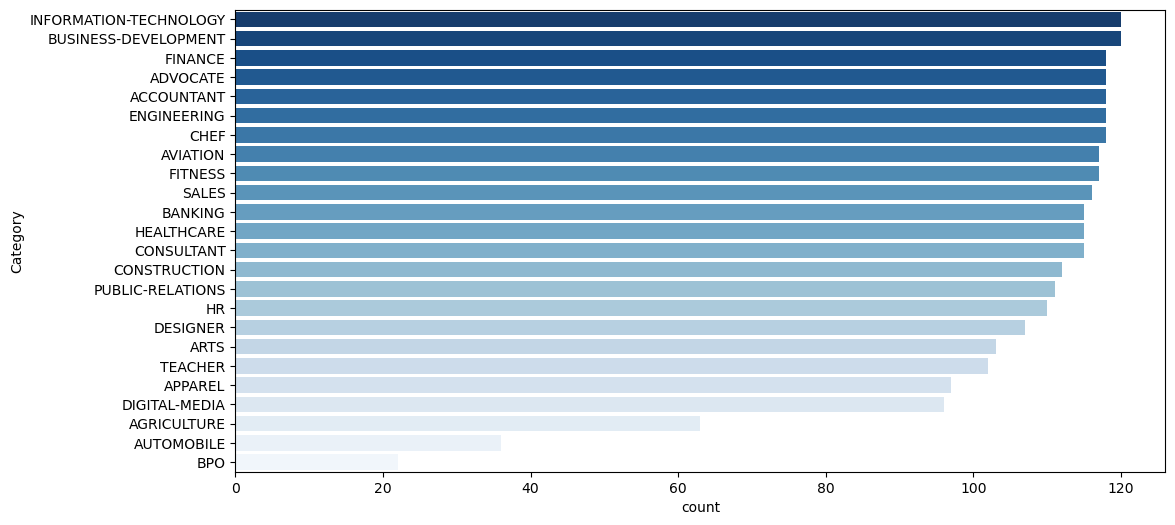

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y='Category',
    order=df['Category'].value_counts().index,
    palette='Blues_r'
)
plt.show()

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_resume'] = df['Resume_str'].apply(clean_text)
print(df['Resume_str'].iloc[0][:200])
print(df['clean_resume'].iloc[0][:200])


         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp
hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams 


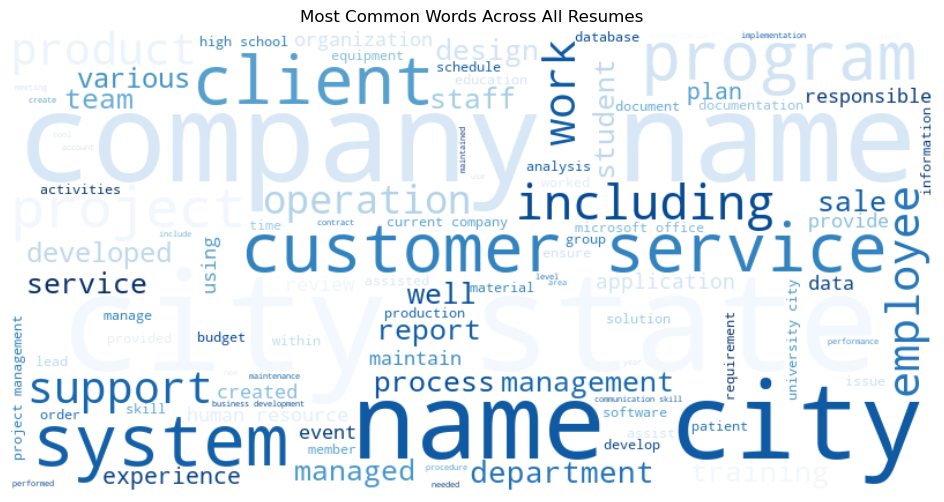

In [7]:
all_text = ' '.join(df['clean_resume'].values)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='Blues'
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words Across All Resumes')
plt.show()

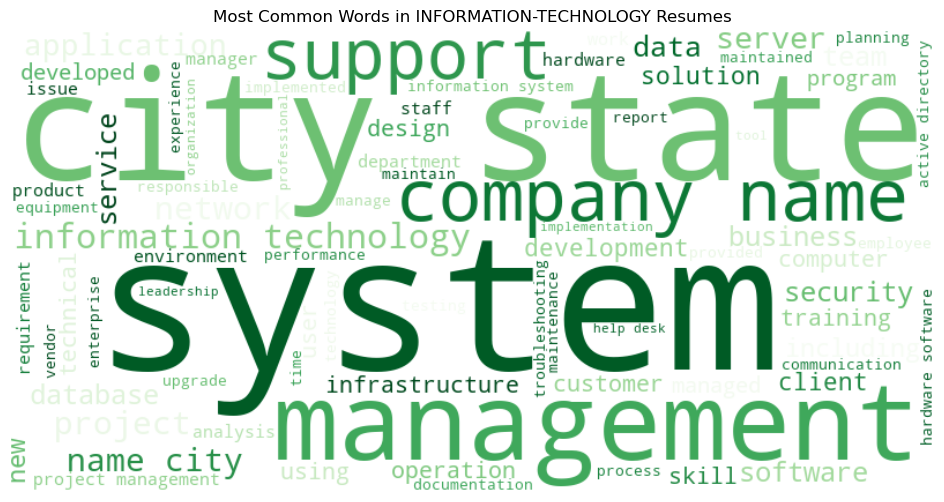

In [8]:
category = 'INFORMATION-TECHNOLOGY'
category_text = ' '.join(df[df['Category'] == category]['clean_resume'].values)

wordcloud_cat = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=80,
    colormap='Greens'
).generate(category_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud_cat, interpolation='bilinear')
plt.axis('off')
plt.title(f'Most Common Words in {category} Resumes')
plt.show()

In [9]:
df.to_csv('Resume_cleaned.csv', index=False)
print("Saved!")

Saved!


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
category_counts = df['Category'].value_counts()
valid_categories = category_counts[category_counts >= 100].index
df_filtered = df[df['Category'].isin(valid_categories)]

print("Original dataset size:", len(df))
print("Filtered dataset size:", len(df_filtered))
print("Remaining categories:", df_filtered['Category'].nunique())
print(df_filtered['Category'].value_counts())


Original dataset size: 2484
Filtered dataset size: 2170
Remaining categories: 19
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
CONSULTANT                115
HEALTHCARE                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
Name: count, dtype: int64


In [11]:
tfidf = TfidfVectorizer(max_features=10000)
X = tfidf.fit_transform(df_filtered['clean_resume'])
y = df_filtered['Category']

print("Shape of X:", X.shape)

Shape of X: (2170, 10000)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1736
Testing samples: 434


In [13]:
#Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf * 100, 2), "%")

Random Forest Accuracy: 67.51 %


In [14]:
#Support Vector Classifier
svc_model = SVC(kernel='linear', random_state=42)
svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)

print("SVC Accuracy:", round(accuracy_svc * 100, 2), "%")

SVC Accuracy: 67.74 %


In [15]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(accuracy_lr * 100, 2), "%")

Logistic Regression Accuracy: 66.82 %


In [16]:
import joblib

# Resave with protocol=2 for compatibility
joblib.dump(lr_model, 'resume_model.pkl', protocol=2)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl', protocol=2)

print("Saved successfully!")

Saved successfully!


In [17]:
from sentence_transformers import SentenceTransformer
# Load pretrained model
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded!


In [18]:
# Convert all resumes to embeddings
print("Creating embeddings... this will take 3-5 minutes, be patient!")

embeddings = embedder.encode(
    df_filtered['clean_resume'].tolist(),
    show_progress_bar=True
)

print("Shape of embeddings:", embeddings.shape)
print("Done!")

Creating embeddings... this will take 3-5 minutes, be patient!


Batches:   0%|          | 0/68 [00:00<?, ?it/s]

Shape of embeddings: (2170, 384)
Done!


In [19]:
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    embeddings,
    df_filtered['Category'],
    test_size=0.2,
    random_state=42,
    stratify=df_filtered['Category']
)

print("Training samples:", X_train_emb.shape[0])
print("Testing samples:", X_test_emb.shape[0])

Training samples: 1736
Testing samples: 434


In [20]:
# Train Logistic Regression on embeddings
lr_emb = LogisticRegression(max_iter=1000)
lr_emb.fit(X_train_emb, y_train_emb)

# Evaluate
y_pred_emb = lr_emb.predict(X_test_emb)
accuracy_emb = accuracy_score(y_test_emb, y_pred_emb)

print("Hugging Face + Logistic Regression Accuracy:", round(accuracy_emb * 100, 2), "%")

Hugging Face + Logistic Regression Accuracy: 73.73 %


In [21]:
from sklearn.svm import SVC

svc_emb = SVC(kernel='rbf', random_state=42, probability=True)
svc_emb.fit(X_train_emb, y_train_emb)

y_pred_svc_emb = svc_emb.predict(X_test_emb)
accuracy_svc_emb = accuracy_score(y_test_emb, y_pred_svc_emb)

print("Hugging Face + SVC Accuracy:", round(accuracy_svc_emb * 100, 2), "%")

Hugging Face + SVC Accuracy: 73.73 %


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_emb = RandomForestClassifier(n_estimators=200, random_state=42)
rf_emb.fit(X_train_emb, y_train_emb)

y_pred_rf_emb = rf_emb.predict(X_test_emb)
accuracy_rf_emb = accuracy_score(y_test_emb, y_pred_rf_emb)

print("Hugging Face + Random Forest Accuracy:", round(accuracy_rf_emb * 100, 2), "%")

Hugging Face + Random Forest Accuracy: 70.51 %


In [23]:
results = {
    'TF-IDF + Logistic Regression': 64.99,
    'TF-IDF + Random Forest': 67.51,
    'TF-IDF + SVC': 65.19,
    'HuggingFace + Logistic Regression': round(accuracy_emb * 100, 2),
    'HuggingFace + SVC': round(accuracy_svc_emb * 100, 2),
    'HuggingFace + Random Forest': 0  # fill after Cell 20
}

import pandas as pd
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

                            Model  Accuracy
HuggingFace + Logistic Regression     73.73
                HuggingFace + SVC     73.73
           TF-IDF + Random Forest     67.51
                     TF-IDF + SVC     65.19
     TF-IDF + Logistic Regression     64.99
      HuggingFace + Random Forest      0.00


In [24]:
import joblib

# Save new model and embedder name
joblib.dump(lr_emb, 'resume_model.pkl')
joblib.dump(embedder, 'embedder.pkl')

print("New model saved!")
print("Old TF-IDF model replaced ✅")

New model saved!
Old TF-IDF model replaced ✅


In [25]:
sample = df_filtered[df_filtered['Category'] == 'INFORMATION-TECHNOLOGY'].iloc[0]
print(sample['Resume_str'][:2000])

         INFORMATION TECHNOLOGY         Summary     Dedicated  Information Assurance Professional  well-versed in analyzing and mitigating risk and finding cost-effective solutions. Excels at boosting performance and productivity by establishing realistic goals and enforcing deadlines.  Versatile IT professional with 37 years of Enterprise design and engineering methodology.       Skills          Enterprise platforms  Knowledge of Product Lifecycle Management (PLM)  Project tracking  Hardware and software upgrade planning  Product requirements documentation  Self-directed  MS Visio  Decisive  Collaborative  Domain Active Directory Layout  Data storage engineering      Information Assurance  Risk Management Framework (RMF)  Active Directory design and deployment  Workstation build and deployment  Systems Accreditation Packages  Red Hat Enterprise Linux installation and hardening  Network Design & Troubleshooting   High Performance Computing            Experience      Company Name    Cit

In [26]:
print(df_filtered['Category'].unique())

['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'SALES' 'CONSULTANT' 'CHEF'
 'FINANCE' 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS'
 'BANKING' 'ARTS' 'AVIATION']


In [27]:
import joblib

joblib.dump(lr_emb, 'resume_model.pkl')
joblib.dump(embedder, 'embedder.pkl')
print("Models resaved!")

Models resaved!


In [28]:
# Load BBC news dataset
bbc_df = pd.read_csv('bbc-text.csv')
print("Shape:", bbc_df.shape)
print("\nColumns:", bbc_df.columns.tolist())
print("\nSample:")
print(bbc_df.head(3))

Shape: (2225, 2)

Columns: ['category', 'text']

Sample:
   category                                               text
0      tech  tv future in the hands of viewers with home th...
1  business  worldcom boss  left books alone  former worldc...
2     sport  tigers wary of farrell  gamble  leicester say ...


In [29]:
# Prepare CV data (label = 1)
cv_data = pd.DataFrame({
    'text': df_filtered['Resume_str'],
    'is_cv': 1
})

# Prepare non-CV data (label = 0)
non_cv_data = pd.DataFrame({
    'text': bbc_df['text'],
    'is_cv': 0
})

# Combine both
cv_classifier_df = pd.concat([cv_data, non_cv_data], ignore_index=True)

# Shuffle the data
cv_classifier_df = cv_classifier_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total samples:", len(cv_classifier_df))
print("\nLabel distribution:")
print(cv_classifier_df['is_cv'].value_counts())
print("\nSample:")
print(cv_classifier_df.head(3))

Total samples: 4395

Label distribution:
is_cv
0    2225
1    2170
Name: count, dtype: int64

Sample:
                                                text  is_cv
0  athens memories soar above lows well  it s goo...      0
1  pavey focuses on indoor success jo pavey will ...      0
2           ACCOUNTANT         Summary    Experie...      1


In [30]:
# Clean the text
cv_classifier_df['clean_text'] = cv_classifier_df['text'].apply(clean_text)

# Create embeddings
print("Creating embeddings... this will take 3-5 minutes")
cv_embeddings = embedder.encode(
    cv_classifier_df['clean_text'].tolist(),
    show_progress_bar=True
)

print("Shape:", cv_embeddings.shape)

Creating embeddings... this will take 3-5 minutes


Batches:   0%|          | 0/138 [00:00<?, ?it/s]

Shape: (4395, 384)


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(
    cv_embeddings,
    cv_classifier_df['is_cv'],
    test_size=0.2,
    random_state=42,
    stratify=cv_classifier_df['is_cv']
)

# Train classifier
cv_classifier = LogisticRegression(max_iter=1000)
cv_classifier.fit(X_train_cv, y_train_cv)

# Evaluate
y_pred_cv = cv_classifier.predict(X_test_cv)
accuracy_cv = accuracy_score(y_test_cv, y_pred_cv)

print("CV Classifier Accuracy:", round(accuracy_cv * 100, 2), "%")
print()
print(classification_report(y_test_cv, y_pred_cv, target_names=['Not CV', 'CV']))

CV Classifier Accuracy: 99.77 %

              precision    recall  f1-score   support

      Not CV       1.00      1.00      1.00       445
          CV       1.00      1.00      1.00       434

    accuracy                           1.00       879
   macro avg       1.00      1.00      1.00       879
weighted avg       1.00      1.00      1.00       879



In [32]:
import joblib

joblib.dump(cv_classifier, 'cv_classifier.pkl')
print("CV classifier saved!")

CV classifier saved!
